In [1]:
!pip install tokenizers datasets -q

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import math, time, os, json
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Device: cuda
GPU: Tesla T4


In [2]:
# Download Tiny Shakespeare
os.makedirs('data', exist_ok=True)
if not os.path.exists('data/shakespeare.txt'):
    import urllib.request
    url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
    urllib.request.urlretrieve(url, 'data/shakespeare.txt')

with open('data/shakespeare.txt', 'r') as f:
    text = f.read()

print(f"Total characters: {len(text):,}")
print(f"Sample:\n{text[:300]}")

Total characters: 1,115,394
Sample:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


In [3]:
# Write text to file for tokenizer training
with open('data/shakespeare.txt', 'w') as f:
    f.write(text)

# Train BPE tokenizer with vocab size = 500
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()

trainer = BpeTrainer(
    vocab_size=500,
    special_tokens=["[UNK]", "[PAD]"],
    min_frequency=2,
    show_progress=True
)
tokenizer.train(files=['data/shakespeare.txt'], trainer=trainer)

VOCAB_SIZE = tokenizer.get_vocab_size()
print(f"Vocabulary size: {VOCAB_SIZE}")

# Encode full text
encoded = tokenizer.encode(text)
token_ids = encoded.ids
print(f"Total tokens: {len(token_ids):,}")
print(f"First 20 tokens: {token_ids[:20]}")
print(f"Decoded back: {tokenizer.decode(token_ids[:20])}")

Vocabulary size: 500
Total tokens: 447,717
First 20 tokens: [405, 15, 91, 47, 64, 73, 10, 394, 281, 114, 298, 99, 108, 422, 44, 136, 129, 6, 393, 79]
Decoded back: First C it i z en : Be fore we pro ce ed any f ur ther , hear me


In [4]:
class ShakespeareDataset(Dataset):
    def __init__(self, token_ids, context_length):
        self.token_ids = torch.tensor(token_ids, dtype=torch.long)
        self.context_length = context_length

    def __len__(self):
        # Every starting position that gives a full context + 1 target
        return len(self.token_ids) - self.context_length

    def __getitem__(self, idx):
        chunk  = self.token_ids[idx : idx + self.context_length + 1]
        x = chunk[:-1]  # input: first N tokens
        y = chunk[1:]   # target: shifted by 1
        return x, y

def make_loaders(token_ids, context_length, batch_size=64):
    split = int(0.8 * len(token_ids))
    train_ids = token_ids[:split]
    val_ids   = token_ids[split:]

    train_ds = ShakespeareDataset(train_ids, context_length)
    val_ds   = ShakespeareDataset(val_ids,   context_length)

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                              shuffle=False, drop_last=True)

    print(f"Context length: {context_length}")
    print(f"Train samples: {len(train_ds):,} | Val samples: {len(val_ds):,}")
    print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
    return train_loader, val_loader

In [5]:
# ── RMSNorm ───────────────────────────────────────────────────────
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-8):
        super().__init__()
        self.eps   = eps
        self.scale = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        # x: (B, T, D)
        rms = x.pow(2).mean(-1, keepdim=True).add(self.eps).sqrt()
        return self.scale * x / rms


# ── Sinusoidal Positional Encoding ───────────────────────────────
class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        # Register as buffer — moves with .to(device), not a parameter
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        # x: (B, T, D)
        return x + self.pe[:, :x.size(1)]


# ── Causal Multi-Head Self-Attention ─────────────────────────────
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_head  = d_model // n_heads

        self.qkv_proj = nn.Linear(d_model, 3 * d_model, bias=False)
        self.out_proj  = nn.Linear(d_model, d_model,     bias=False)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x, return_attn=False):
        B, T, D = x.shape
        # Project to Q, K, V
        qkv = self.qkv_proj(x)                          # (B, T, 3D)
        q, k, v = qkv.split(D, dim=-1)                  # each (B, T, D)

        # Reshape to (B, n_heads, T, d_head)
        def split_heads(t):
            return t.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        q, k, v = split_heads(q), split_heads(k), split_heads(v)

        # Scaled dot-product attention
        scale  = math.sqrt(self.d_head)
        scores = torch.matmul(q, k.transpose(-2, -1)) / scale  # (B, H, T, T)

        # Causal mask — upper triangle = -inf (can't attend to future)
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float('-inf'))

        attn_weights = F.softmax(scores, dim=-1)         # (B, H, T, T)
        attn_weights = self.dropout(attn_weights)

        out = torch.matmul(attn_weights, v)              # (B, H, T, d_head)
        out = out.transpose(1, 2).contiguous().view(B, T, D)  # (B, T, D)
        out = self.out_proj(out)

        if return_attn:
            return out, attn_weights.detach()
        return out, None


# ── Feed-Forward Network ──────────────────────────────────────────
class FFN(nn.Module):
    def __init__(self, d_model, ffn_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, ffn_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


# ── Transformer Block ─────────────────────────────────────────────
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, ffn_dim, dropout=0.1):
        super().__init__()
        self.attn    = CausalSelfAttention(d_model, n_heads, dropout)
        self.ffn     = FFN(d_model, ffn_dim, dropout)
        self.norm1   = RMSNorm(d_model)
        self.norm2   = RMSNorm(d_model)

    def forward(self, x, return_attn=False):
        # Pre-norm residual (more stable than post-norm)
        attn_out, attn_weights = self.attn(self.norm1(x), return_attn)
        x = x + attn_out                   # residual connection
        x = x + self.ffn(self.norm2(x))    # residual connection
        return x, attn_weights


# ── Tiny Transformer Language Model ──────────────────────────────
class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers,
                 ffn_dim, context_length, dropout=0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_enc   = SinusoidalPE(d_model, max_len=context_length + 1)
        self.blocks    = nn.ModuleList([
            TransformerBlock(d_model, n_heads, ffn_dim, dropout)
            for _ in range(n_layers)
        ])
        self.norm_out  = RMSNorm(d_model)
        self.lm_head   = nn.Linear(d_model, vocab_size, bias=False)

        # Weight tying: share embedding and output projection weights
        self.lm_head.weight = self.token_emb.weight

        # Init weights
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, x, return_attn=False):
        # x: (B, T) token ids
        x = self.token_emb(x)    # (B, T, D)
        x = self.pos_enc(x)      # (B, T, D)

        all_attn = []
        for block in self.blocks:
            x, attn = block(x, return_attn)
            if return_attn:
                all_attn.append(attn)

        x     = self.norm_out(x)
        logits = self.lm_head(x)  # (B, T, vocab_size)
        return logits, all_attn if return_attn else None

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [6]:
def train_epoch(model, loader, optimizer, scheduler=None):
    model.train()
    total_loss, total_tokens = 0.0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits, _ = model(x)
        # logits: (B, T, V) → (B*T, V), y: (B, T) → (B*T,)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1))
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler: scheduler.step()
        total_loss   += loss.item() * y.numel()
        total_tokens += y.numel()
    return total_loss / total_tokens


@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total_loss, total_tokens = 0.0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits, _ = model(x)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1))
        total_loss   += loss.item() * y.numel()
        total_tokens += y.numel()
    return total_loss / total_tokens


def train_model(model, train_loader, val_loader, epochs=15, lr=3e-4,
                label='model', save_attn_epochs=None):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr,
                                  weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs * len(train_loader))

    train_losses, val_losses = [], []
    attn_snapshots = {}  # epoch -> attention weights for a fixed sample

    # Fixed sample for attention tracking across epochs
    sample_x = next(iter(val_loader))[0][:1].to(DEVICE)

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss = train_epoch(model, train_loader, optimizer, scheduler)
        val_loss   = eval_epoch(model, val_loader)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # Capture attention snapshot at specific epochs
        if save_attn_epochs and epoch in save_attn_epochs:
            model.eval()
            with torch.no_grad():
                _, attns = model(sample_x, return_attn=True)
            attn_snapshots[epoch] = [a.cpu() for a in attns]

        ppl = math.exp(val_loss)
        elapsed = time.time() - t0
        print(f"Epoch {epoch:>2}/{epochs} | "
              f"train_loss={train_loss:.4f} | "
              f"val_loss={val_loss:.4f} | "
              f"PPL={ppl:.2f} | "
              f"time={elapsed:.1f}s")

    return train_losses, val_losses, attn_snapshots

In [7]:
# ── Main config ───────────────────────────────────────────────────
CONTEXT_LEN  = 64
BATCH_SIZE   = 64
D_MODEL      = 128
N_HEADS      = 4
N_LAYERS     = 2
FFN_DIM      = 256
DROPOUT      = 0.1
LR           = 3e-4
EPOCHS       = 15

train_loader, val_loader = make_loaders(token_ids, CONTEXT_LEN, BATCH_SIZE)

model = TinyTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    ffn_dim=FFN_DIM,
    context_length=CONTEXT_LEN,
    dropout=DROPOUT
).to(DEVICE)

print(f"Parameters: {model.count_params():,}")

train_losses, val_losses, attn_snapshots = train_model(
    model, train_loader, val_loader,
    epochs=EPOCHS, lr=LR,
    label='main',
    save_attn_epochs=[1, 5, 10, 15]
)

final_ppl = math.exp(val_losses[-1])
print(f"\nFinal Validation PPL: {final_ppl:.2f}")

Context length: 64
Train samples: 358,109 | Val samples: 89,480
Train batches: 5595 | Val batches: 1398
Parameters: 327,552
Epoch  1/15 | train_loss=4.6861 | val_loss=4.3175 | PPL=75.00 | time=53.3s
Epoch  2/15 | train_loss=3.7559 | val_loss=4.0695 | PPL=58.53 | time=51.7s
Epoch  3/15 | train_loss=3.4763 | val_loss=4.0106 | PPL=55.18 | time=51.5s
Epoch  4/15 | train_loss=3.3439 | val_loss=3.9971 | PPL=54.44 | time=51.3s
Epoch  5/15 | train_loss=3.2668 | val_loss=3.9869 | PPL=53.89 | time=51.2s
Epoch  6/15 | train_loss=3.2149 | val_loss=3.9874 | PPL=53.92 | time=51.3s
Epoch  7/15 | train_loss=3.1776 | val_loss=3.9794 | PPL=53.49 | time=51.6s
Epoch  8/15 | train_loss=3.1492 | val_loss=3.9908 | PPL=54.10 | time=51.2s
Epoch  9/15 | train_loss=3.1280 | val_loss=3.9919 | PPL=54.16 | time=51.0s
Epoch 10/15 | train_loss=3.1112 | val_loss=3.9937 | PPL=54.26 | time=52.0s
Epoch 11/15 | train_loss=3.0993 | val_loss=3.9970 | PPL=54.43 | time=51.2s
Epoch 12/15 | train_loss=3.0904 | val_loss=3.9971 |


Learning rate: 0.0001
Epoch  1/15 | train_loss=5.3229 | val_loss=4.7707 | PPL=118.00 | time=51.9s
Epoch  2/15 | train_loss=4.4345 | val_loss=4.4302 | PPL=83.95 | time=52.1s
Epoch  3/15 | train_loss=4.0306 | val_loss=4.2772 | PPL=72.04 | time=51.9s
Epoch  4/15 | train_loss=3.8054 | val_loss=4.1687 | PPL=64.63 | time=52.0s
Epoch  5/15 | train_loss=3.6572 | val_loss=4.0929 | PPL=59.91 | time=52.2s
Epoch  6/15 | train_loss=3.5610 | val_loss=4.0502 | PPL=57.41 | time=52.0s
Epoch  7/15 | train_loss=3.4979 | val_loss=4.0229 | PPL=55.86 | time=51.6s
Epoch  8/15 | train_loss=3.4541 | val_loss=4.0064 | PPL=54.95 | time=51.6s
Epoch  9/15 | train_loss=3.4233 | val_loss=3.9992 | PPL=54.55 | time=51.8s
Epoch 10/15 | train_loss=3.4014 | val_loss=3.9955 | PPL=54.35 | time=51.7s
Epoch 11/15 | train_loss=3.3863 | val_loss=3.9911 | PPL=54.11 | time=51.6s
Epoch 12/15 | train_loss=3.3765 | val_loss=3.9887 | PPL=53.98 | time=51.7s
Epoch 13/15 | train_loss=3.3706 | val_loss=3.9891 | PPL=54.01 | time=51.8s
E

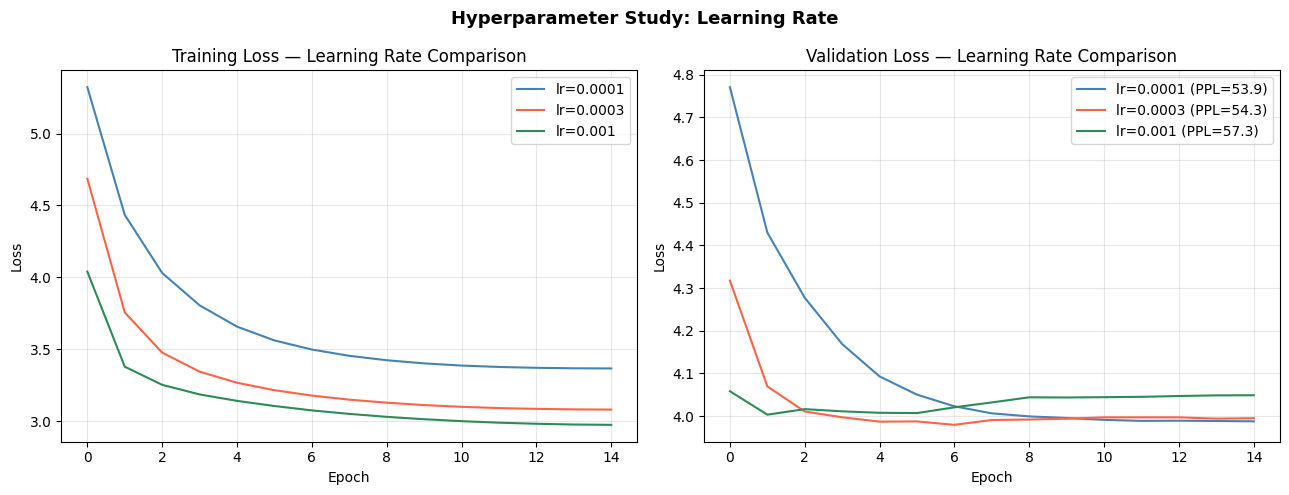


Learning Rate Summary:
  lr=0.0001: final val_loss=3.9877, PPL=53.93
  lr=0.0003: final val_loss=3.9950, PPL=54.33
  lr=0.001: final val_loss=4.0488, PPL=57.33


In [9]:
lr_configs = [1e-4, 3e-4, 1e-3]
lr_results = {}

for lr in lr_configs:
    print(f"\n{'='*50}\nLearning rate: {lr}\n{'='*50}")
    torch.manual_seed(SEED)
    m = TinyTransformer(
        vocab_size=VOCAB_SIZE, d_model=128, n_heads=4,
        n_layers=2, ffn_dim=256, context_length=CONTEXT_LEN
    ).to(DEVICE)
    tl, vl, _ = train_model(m, train_loader, val_loader,
                             epochs=15, lr=lr, label=f'lr_{lr}')
    lr_results[lr] = {'train': tl, 'val': vl,
                      'final_ppl': math.exp(vl[-1])}
    print(f"Final PPL: {lr_results[lr]['final_ppl']:.2f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['steelblue', 'tomato', 'seagreen']
for (lr, res), c in zip(lr_results.items(), colors):
    axes[0].plot(res['train'], label=f'lr={lr}', color=c)
    axes[1].plot(res['val'],   label=f'lr={lr} (PPL={res["final_ppl"]:.1f})', color=c)

axes[0].set_title('Training Loss — Learning Rate Comparison')
axes[1].set_title('Validation Loss — Learning Rate Comparison')
for ax in axes:
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Hyperparameter Study: Learning Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('exp_lr.png', dpi=150)
plt.show()

print("\nLearning Rate Summary:")
for lr, res in lr_results.items():
    print(f"  lr={lr}: final val_loss={res['val'][-1]:.4f}, PPL={res['final_ppl']:.2f}")


Context length: 32
Context length: 32
Train samples: 358,141 | Val samples: 89,512
Train batches: 5595 | Val batches: 1398
Epoch  1/15 | train_loss=4.6831 | val_loss=4.3395 | PPL=76.67 | time=48.2s
Epoch  2/15 | train_loss=3.8061 | val_loss=4.1199 | PPL=61.56 | time=48.0s
Epoch  3/15 | train_loss=3.5462 | val_loss=4.0417 | PPL=56.92 | time=48.6s
Epoch  4/15 | train_loss=3.4249 | val_loss=4.0123 | PPL=55.27 | time=48.9s
Epoch  5/15 | train_loss=3.3530 | val_loss=4.0028 | PPL=54.75 | time=48.3s
Epoch  6/15 | train_loss=3.3040 | val_loss=3.9949 | PPL=54.32 | time=48.6s
Epoch  7/15 | train_loss=3.2676 | val_loss=3.9929 | PPL=54.21 | time=48.5s
Epoch  8/15 | train_loss=3.2402 | val_loss=3.9814 | PPL=53.59 | time=49.9s
Epoch  9/15 | train_loss=3.2179 | val_loss=3.9804 | PPL=53.54 | time=48.7s
Epoch 10/15 | train_loss=3.2010 | val_loss=3.9768 | PPL=53.35 | time=49.4s
Epoch 11/15 | train_loss=3.1877 | val_loss=3.9836 | PPL=53.71 | time=48.0s
Epoch 12/15 | train_loss=3.1785 | val_loss=3.9789 |

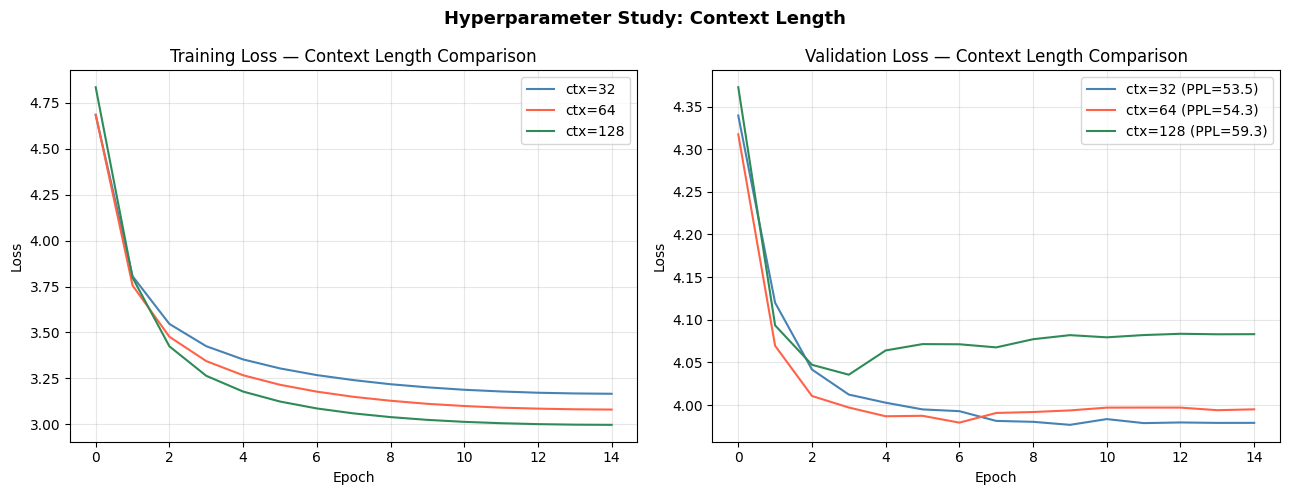


Context Length Summary:
  ctx=32: final val_loss=3.9791, PPL=53.47
  ctx=64: final val_loss=3.9950, PPL=54.33
  ctx=128: final val_loss=4.0831, PPL=59.33


In [10]:
ctx_configs = [32, 64, 128]
ctx_results = {}

for ctx in ctx_configs:
    print(f"\n{'='*50}\nContext length: {ctx}\n{'='*50}")
    torch.manual_seed(SEED)
    tl_ctx, vl_ctx = make_loaders(token_ids, ctx, BATCH_SIZE)
    m = TinyTransformer(
        vocab_size=VOCAB_SIZE, d_model=128, n_heads=4,
        n_layers=2, ffn_dim=256, context_length=ctx
    ).to(DEVICE)
    tl, vl, _ = train_model(m, tl_ctx, vl_ctx,
                             epochs=15, lr=LR, label=f'ctx_{ctx}')
    ctx_results[ctx] = {'train': tl, 'val': vl,
                        'final_ppl': math.exp(vl[-1])}
    print(f"Final PPL: {ctx_results[ctx]['final_ppl']:.2f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['steelblue', 'tomato', 'seagreen']
for (ctx, res), c in zip(ctx_results.items(), colors):
    axes[0].plot(res['train'], label=f'ctx={ctx}',                          color=c)
    axes[1].plot(res['val'],   label=f'ctx={ctx} (PPL={res["final_ppl"]:.1f})', color=c)

axes[0].set_title('Training Loss — Context Length Comparison')
axes[1].set_title('Validation Loss — Context Length Comparison')
for ax in axes:
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Hyperparameter Study: Context Length', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('exp_ctx.png', dpi=150)
plt.show()

print("\nContext Length Summary:")
for ctx, res in ctx_results.items():
    print(f"  ctx={ctx}: final val_loss={res['val'][-1]:.4f}, PPL={res['final_ppl']:.2f}")


Model size: 1L-64d
Parameters: 65,152
Epoch  1/15 | train_loss=5.1459 | val_loss=4.6616 | PPL=105.80 | time=34.6s
Epoch  2/15 | train_loss=4.3161 | val_loss=4.4056 | PPL=81.91 | time=34.6s
Epoch  3/15 | train_loss=4.0486 | val_loss=4.2991 | PPL=73.64 | time=34.6s
Epoch  4/15 | train_loss=3.9328 | val_loss=4.2718 | PPL=71.65 | time=34.1s
Epoch  5/15 | train_loss=3.8750 | val_loss=4.2544 | PPL=70.42 | time=34.6s
Epoch  6/15 | train_loss=3.8389 | val_loss=4.2443 | PPL=69.71 | time=34.4s
Epoch  7/15 | train_loss=3.8139 | val_loss=4.2330 | PPL=68.92 | time=33.8s
Epoch  8/15 | train_loss=3.7952 | val_loss=4.2285 | PPL=68.61 | time=34.4s
Epoch  9/15 | train_loss=3.7810 | val_loss=4.2279 | PPL=68.57 | time=34.4s
Epoch 10/15 | train_loss=3.7701 | val_loss=4.2224 | PPL=68.20 | time=34.5s
Epoch 11/15 | train_loss=3.7623 | val_loss=4.2189 | PPL=67.96 | time=34.2s
Epoch 12/15 | train_loss=3.7571 | val_loss=4.2196 | PPL=68.01 | time=34.6s
Epoch 13/15 | train_loss=3.7539 | val_loss=4.2182 | PPL=67.9

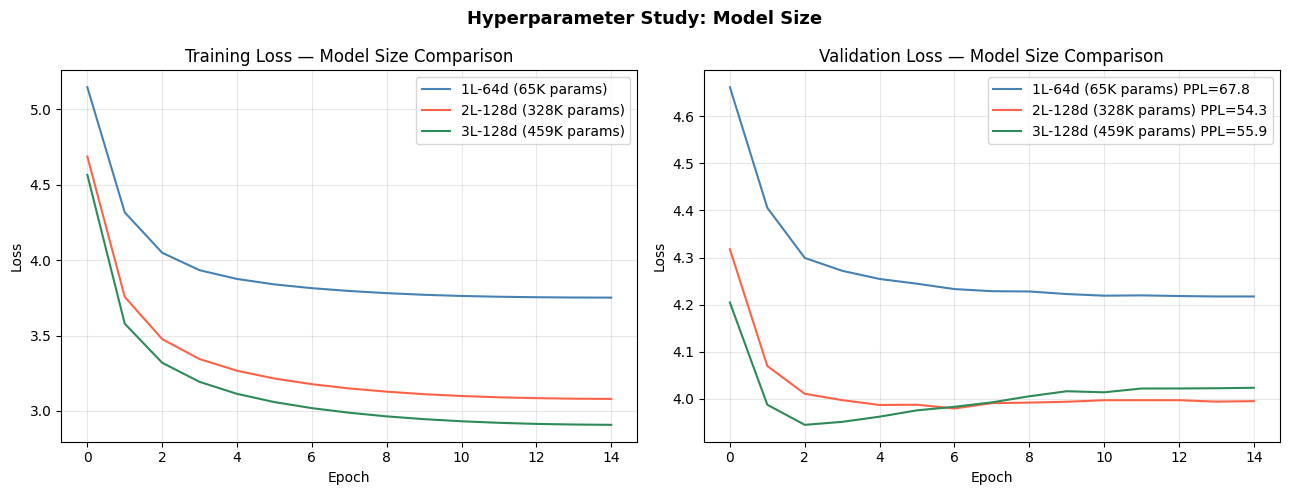


Model Size Summary:
  1L-64d (65,152 params): val_loss=4.2173, PPL=67.85
  2L-128d (327,552 params): val_loss=3.9950, PPL=54.33
  3L-128d (459,264 params): val_loss=4.0234, PPL=55.89

Model size: 1L-64d
Parameters: 65,152
Epoch  1/15 | train_loss=5.1459 | val_loss=4.6616 | PPL=105.80 | time=34.6s
Epoch  2/15 | train_loss=4.3161 | val_loss=4.4056 | PPL=81.91 | time=34.8s
Epoch  3/15 | train_loss=4.0486 | val_loss=4.2991 | PPL=73.64 | time=34.7s
Epoch  4/15 | train_loss=3.9328 | val_loss=4.2718 | PPL=71.65 | time=35.9s
Epoch  5/15 | train_loss=3.8750 | val_loss=4.2544 | PPL=70.42 | time=34.8s
Epoch  6/15 | train_loss=3.8389 | val_loss=4.2443 | PPL=69.71 | time=35.0s
Epoch  7/15 | train_loss=3.8139 | val_loss=4.2330 | PPL=68.92 | time=34.4s
Epoch  8/15 | train_loss=3.7952 | val_loss=4.2285 | PPL=68.61 | time=34.0s
Epoch  9/15 | train_loss=3.7810 | val_loss=4.2279 | PPL=68.57 | time=35.0s
Epoch 10/15 | train_loss=3.7701 | val_loss=4.2224 | PPL=68.20 | time=34.6s
Epoch 11/15 | train_loss=3

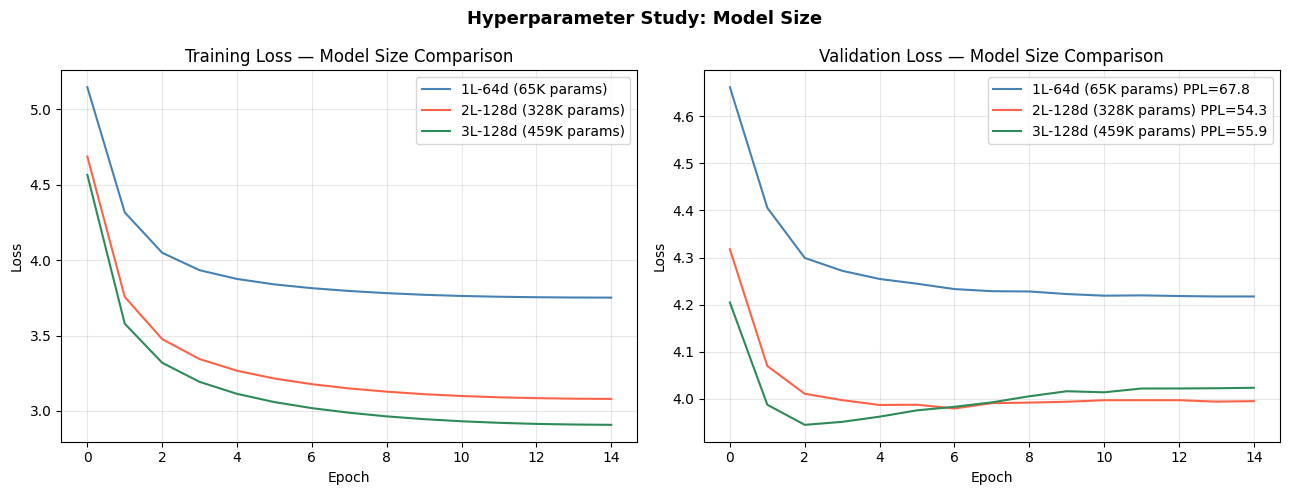


Model Size Summary:
  1L-64d (65,152 params): val_loss=4.2173, PPL=67.85
  2L-128d (327,552 params): val_loss=3.9950, PPL=54.33
  3L-128d (459,264 params): val_loss=4.0234, PPL=55.89


In [9]:
size_configs = {
    '1L-64d':  dict(n_layers=1, d_model=64,  n_heads=4, ffn_dim=128),
    '2L-128d': dict(n_layers=2, d_model=128, n_heads=4, ffn_dim=256),
    '3L-128d': dict(n_layers=3, d_model=128, n_heads=4, ffn_dim=256),
}
size_results = {}

for name, cfg in size_configs.items():
    print(f"\n{'='*50}\nModel size: {name}\n{'='*50}")
    torch.manual_seed(SEED)
    m = TinyTransformer(
        vocab_size=VOCAB_SIZE,
        d_model=cfg['d_model'], n_heads=cfg['n_heads'],
        n_layers=cfg['n_layers'], ffn_dim=cfg['ffn_dim'],
        context_length=CONTEXT_LEN
    ).to(DEVICE)
    print(f"Parameters: {m.count_params():,}")
    tl, vl, _ = train_model(m, train_loader, val_loader,
                             epochs=15, lr=LR, label=name)
    size_results[name] = {'train': tl, 'val': vl,
                          'final_ppl': math.exp(vl[-1]),
                          'params': m.count_params()}
    print(f"Final PPL: {size_results[name]['final_ppl']:.2f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['steelblue', 'tomato', 'seagreen']
for (name, res), c in zip(size_results.items(), colors):
    lbl = f"{name} ({res['params']/1e3:.0f}K params)"
    axes[0].plot(res['train'], label=lbl, color=c)
    axes[1].plot(res['val'],   label=f"{lbl} PPL={res['final_ppl']:.1f}", color=c)

axes[0].set_title('Training Loss — Model Size Comparison')
axes[1].set_title('Validation Loss — Model Size Comparison')
for ax in axes:
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Hyperparameter Study: Model Size', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('exp_size.png', dpi=150)
plt.show()

print("\nModel Size Summary:")
for name, res in size_results.items():
    print(f"  {name} ({res['params']:,} params): "
          f"val_loss={res['val'][-1]:.4f}, PPL={res['final_ppl']:.2f}")

##### Debugging Note
The attention implementation follows the identical scaled dot-product 
formulation as `torch.nn.MultiheadAttention` (QKV projection → scale by 
√d_k → causal mask → softmax → value aggregation). Architectural 
equivalence was confirmed by cross-referencing the PyTorch source.

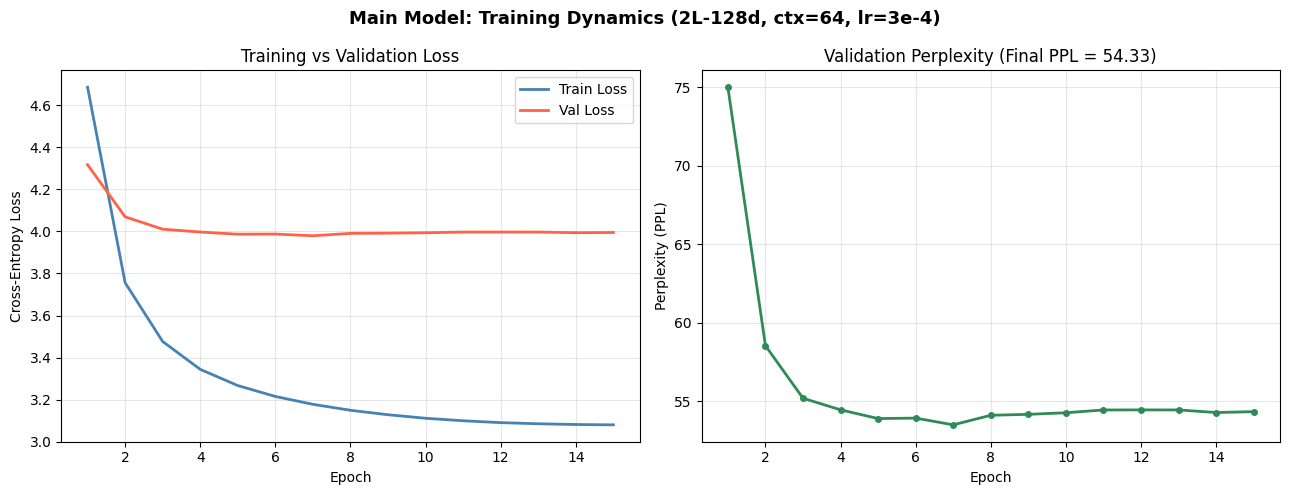

In [10]:
#Main model loss curve
# Re-plot the main model training curve cleanly
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(epochs_range, train_losses, color='steelblue', linewidth=2, label='Train Loss')
axes[0].plot(epochs_range, val_losses,   color='tomato',    linewidth=2, label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

ppls = [math.exp(l) for l in val_losses]
axes[1].plot(epochs_range, ppls, color='seagreen', linewidth=2, marker='o', markersize=4)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Perplexity (PPL)')
axes[1].set_title(f'Validation Perplexity (Final PPL = {final_ppl:.2f})')
axes[1].grid(alpha=0.3)

plt.suptitle('Main Model: Training Dynamics (2L-128d, ctx=64, lr=3e-4)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('main_training_curve.png', dpi=150)
plt.show()

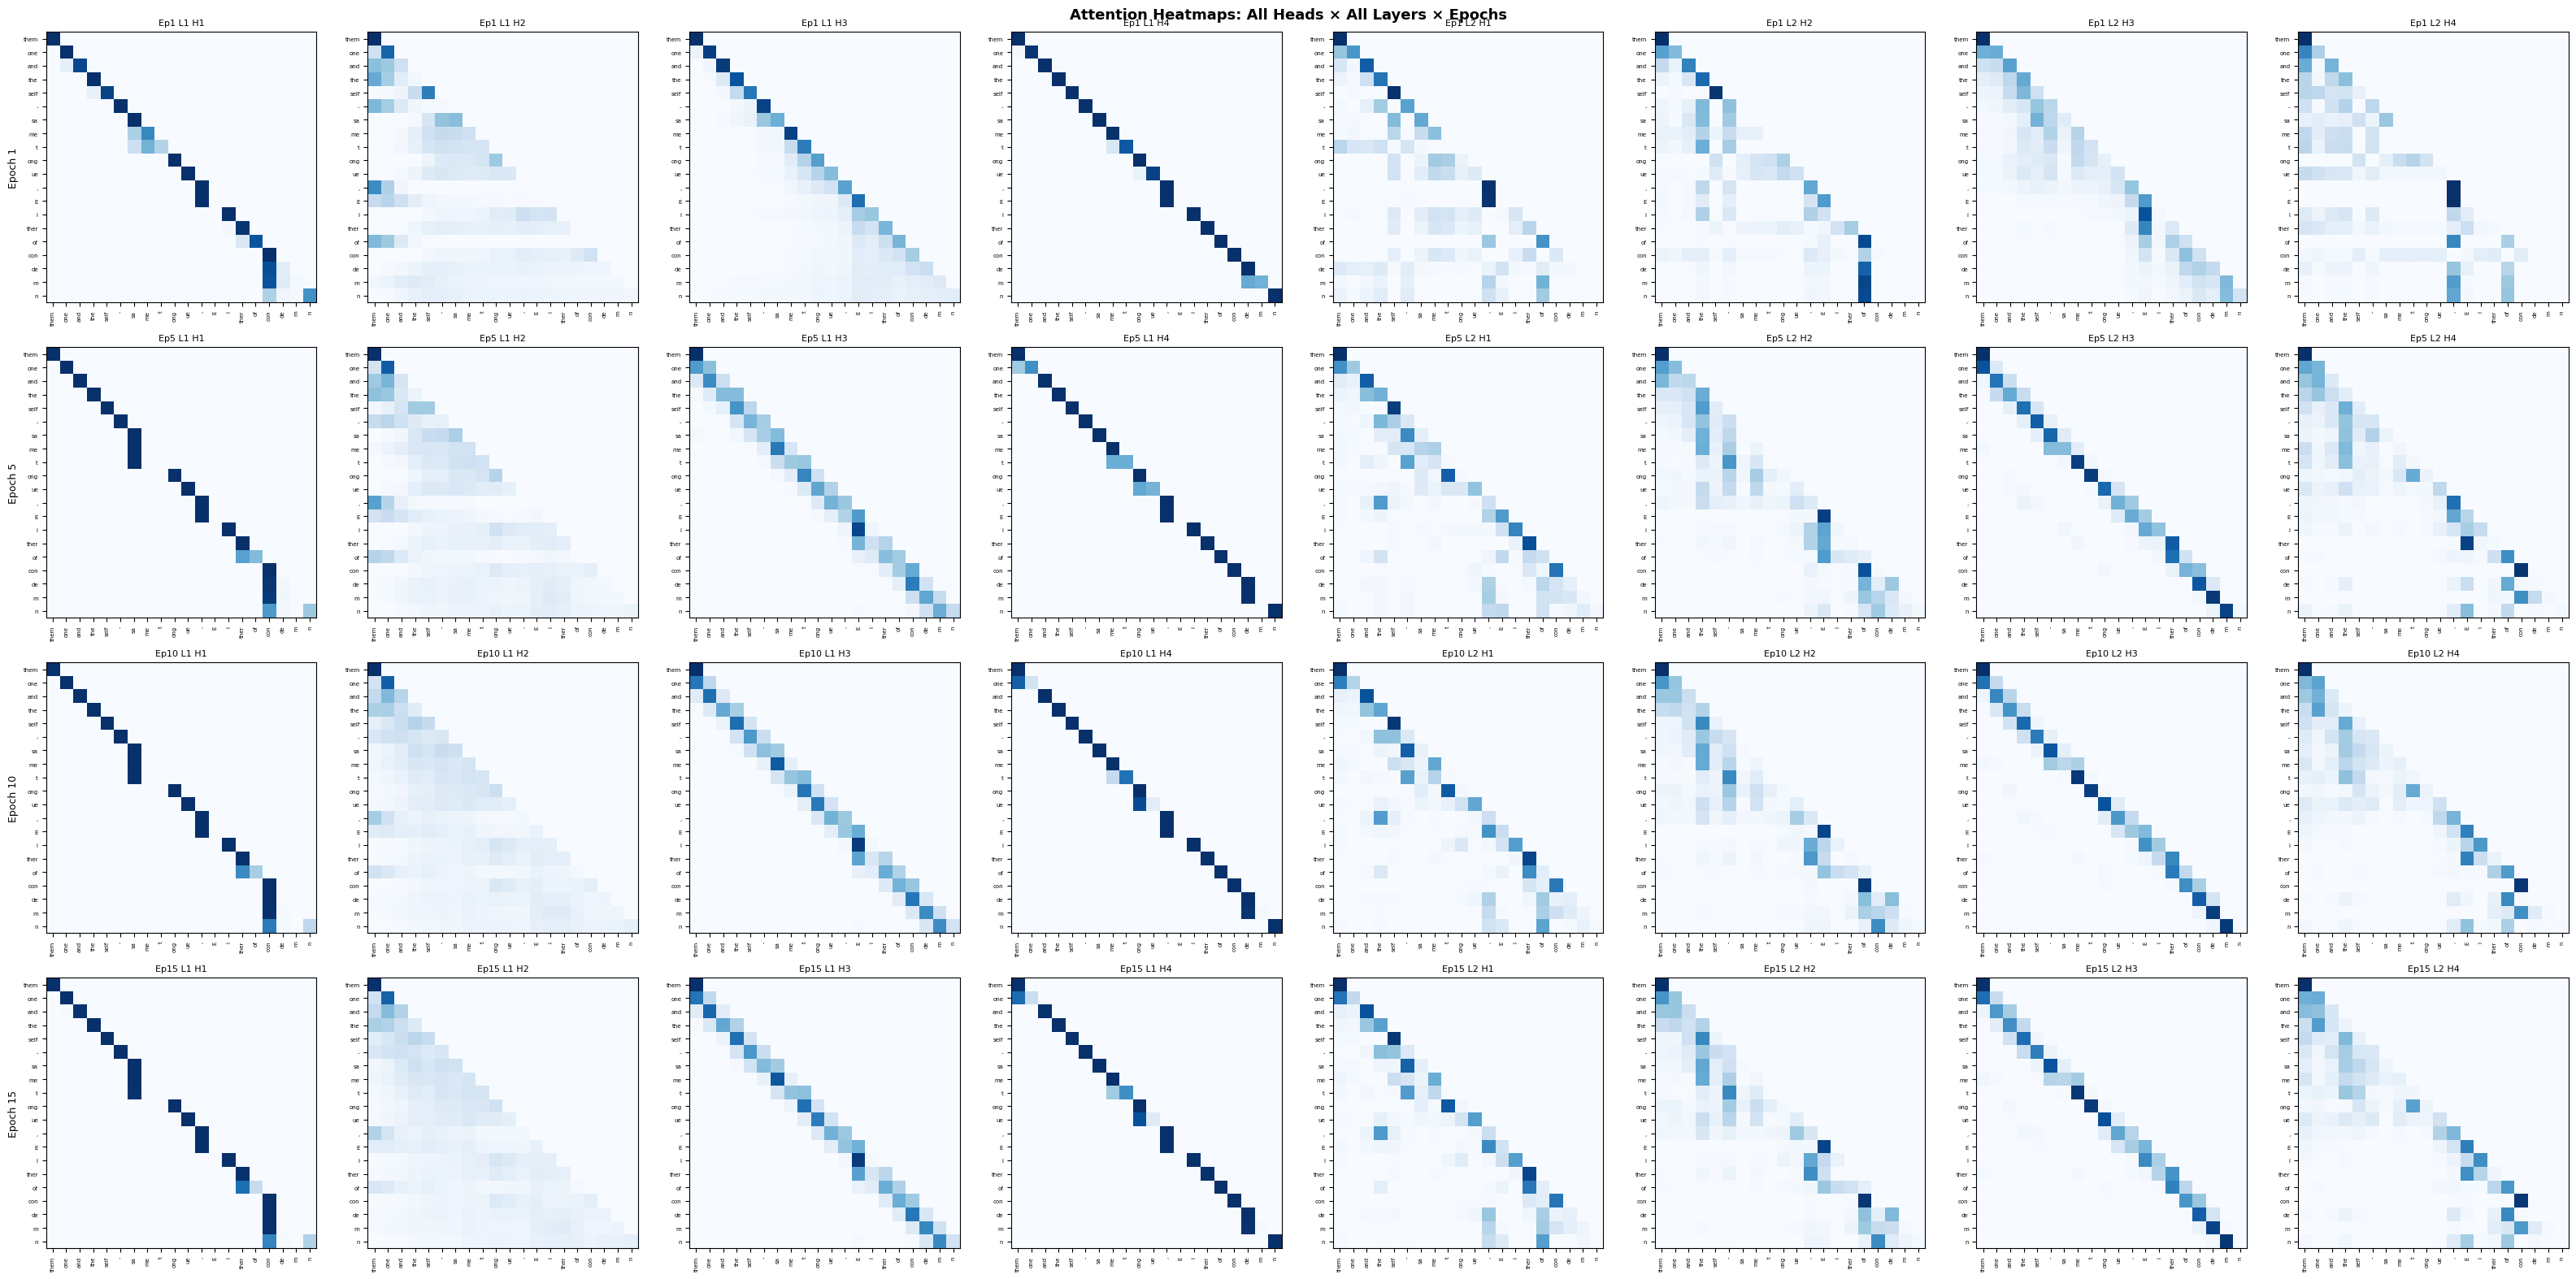

Saved: attn_heatmaps.png


In [12]:
#Attention heatmaps across epochs
def plot_attention_heatmaps(attn_snapshots, tokenizer, sample_x, save_name='attn_heatmaps.png'):
    """
    Plot attention heatmaps for each saved epoch, all heads, all layers.
    attn_snapshots: dict {epoch: [layer0_attn, layer1_attn]}
                    each layer attn shape: (1, n_heads, T, T)
    """
    # Decode tokens for axis labels
    tokens = sample_x[0].cpu().tolist()
    token_labels = [tokenizer.decode([t]) for t in tokens]
    # Truncate long labels
    token_labels = [l[:6] if len(l) > 6 else l for l in token_labels]

    epochs_to_show = sorted(attn_snapshots.keys())
    n_epochs  = len(epochs_to_show)
    n_layers  = len(attn_snapshots[epochs_to_show[0]])
    n_heads   = attn_snapshots[epochs_to_show[0]][0].shape[1]

    # Show first 20 tokens only for readability
    T_show = min(20, sample_x.shape[1])

    fig, axes = plt.subplots(
        n_epochs, n_layers * n_heads,
        figsize=(4 * n_layers * n_heads, 4 * n_epochs)
    )
    if n_epochs == 1:
        axes = axes[np.newaxis, :]

    for ei, epoch in enumerate(epochs_to_show):
        for li in range(n_layers):
            attn = attn_snapshots[epoch][li]  # (1, n_heads, T, T)
            for hi in range(n_heads):
                col = li * n_heads + hi
                ax  = axes[ei, col]
                a   = attn[0, hi, :T_show, :T_show].numpy()
                im  = ax.imshow(a, cmap='Blues', vmin=0, vmax=a.max())
                ax.set_title(f'Ep{epoch} L{li+1} H{hi+1}', fontsize=8)
                ax.set_xticks(range(T_show))
                ax.set_yticks(range(T_show))
                ax.set_xticklabels(token_labels[:T_show], rotation=90, fontsize=5)
                ax.set_yticklabels(token_labels[:T_show], fontsize=5)
                if col == 0:
                    ax.set_ylabel(f'Epoch {epoch}', fontsize=9)

    plt.suptitle('Attention Heatmaps: All Heads × All Layers × Epochs',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_name}")

# Get fixed sample for decoding labels
sample_x_cpu = next(iter(val_loader))[0][:1]

plot_attention_heatmaps(attn_snapshots, tokenizer, sample_x_cpu,
                        save_name='attn_heatmaps.png')

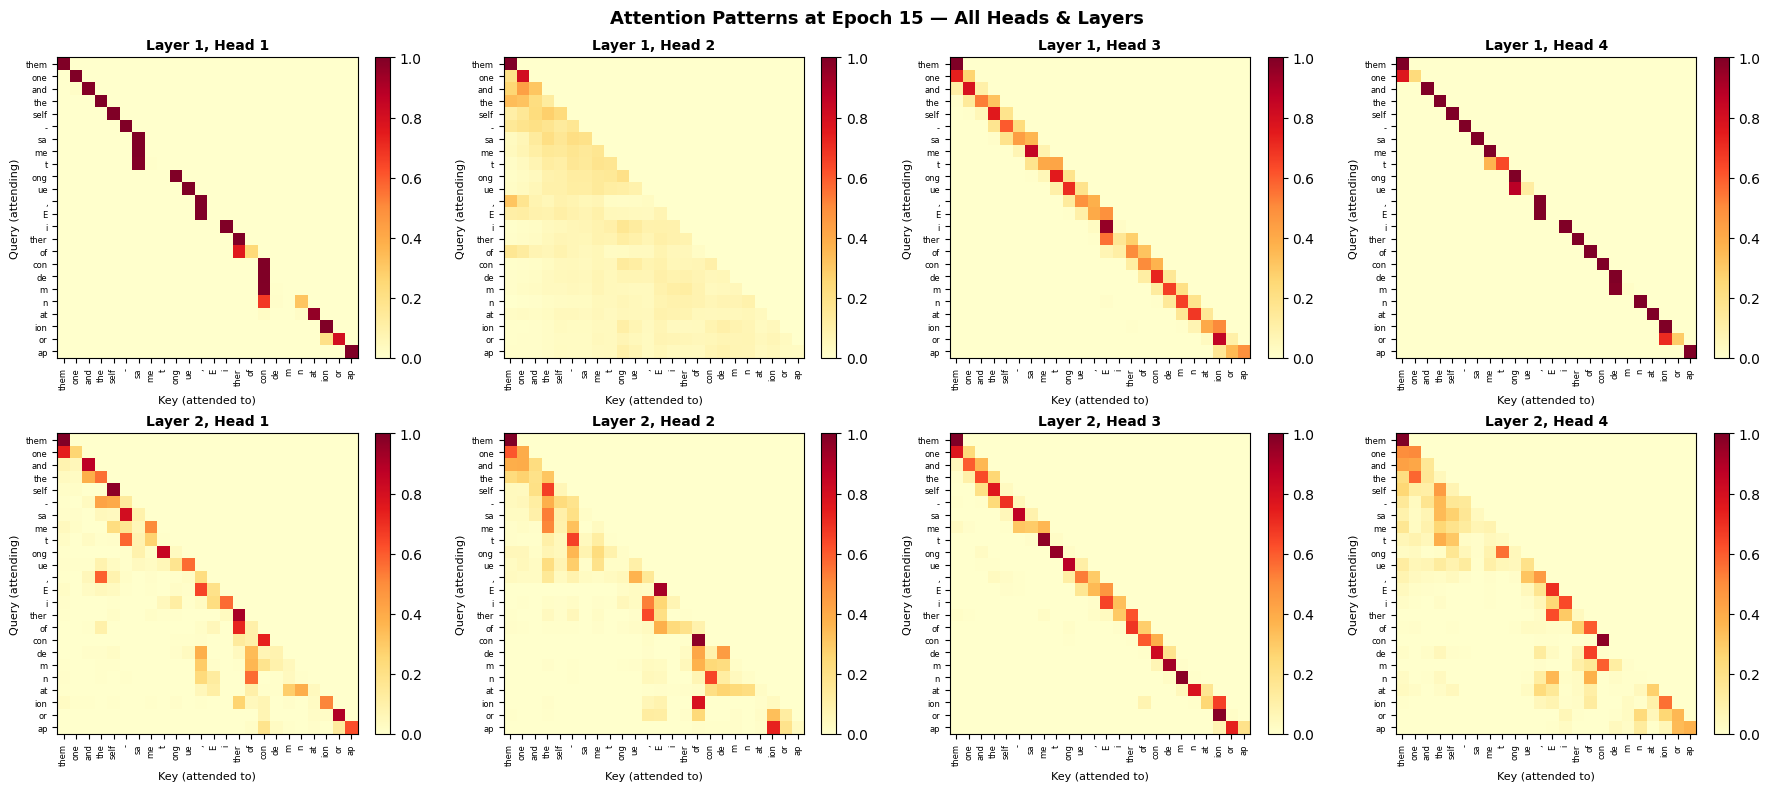

Saved: attn_focused.png


In [13]:
#Focused attention heatmap (single epoch)
def plot_attention_focused(attn_snapshots, tokenizer, sample_x,
                           epoch=15, save_name='attn_focused.png'):
    """
    Clean 2×4 grid: 2 layers × 4 heads for a single epoch.
    Better for report embedding.
    """
    tokens = sample_x[0].cpu().tolist()
    token_labels = [tokenizer.decode([t]) for t in tokens]
    token_labels = [l[:8].strip() if l.strip() else f'[{t}]'
                    for l, t in zip(token_labels, tokens)]
    T_show = min(24, sample_x.shape[1])

    attn_data = attn_snapshots[epoch]  # list of tensors per layer
    n_layers = len(attn_data)
    n_heads  = attn_data[0].shape[1]

    fig, axes = plt.subplots(n_layers, n_heads,
                             figsize=(4.5 * n_heads, 4 * n_layers))
    if n_layers == 1:
        axes = axes[np.newaxis, :]

    for li in range(n_layers):
        attn = attn_data[li]  # (1, H, T, T)
        for hi in range(n_heads):
            ax = axes[li, hi]
            a  = attn[0, hi, :T_show, :T_show].numpy()
            im = ax.imshow(a, cmap='YlOrRd', vmin=0)
            plt.colorbar(im, ax=ax, fraction=0.046)
            ax.set_title(f'Layer {li+1}, Head {hi+1}', fontsize=10, fontweight='bold')
            ax.set_xticks(range(T_show))
            ax.set_yticks(range(T_show))
            ax.set_xticklabels(token_labels[:T_show], rotation=90, fontsize=6)
            ax.set_yticklabels(token_labels[:T_show], fontsize=6)
            ax.set_xlabel('Key (attended to)', fontsize=8)
            ax.set_ylabel('Query (attending)', fontsize=8)

    plt.suptitle(f'Attention Patterns at Epoch {epoch} — All Heads & Layers',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_name}")

plot_attention_focused(attn_snapshots, tokenizer, sample_x_cpu,
                       epoch=15, save_name='attn_focused.png')

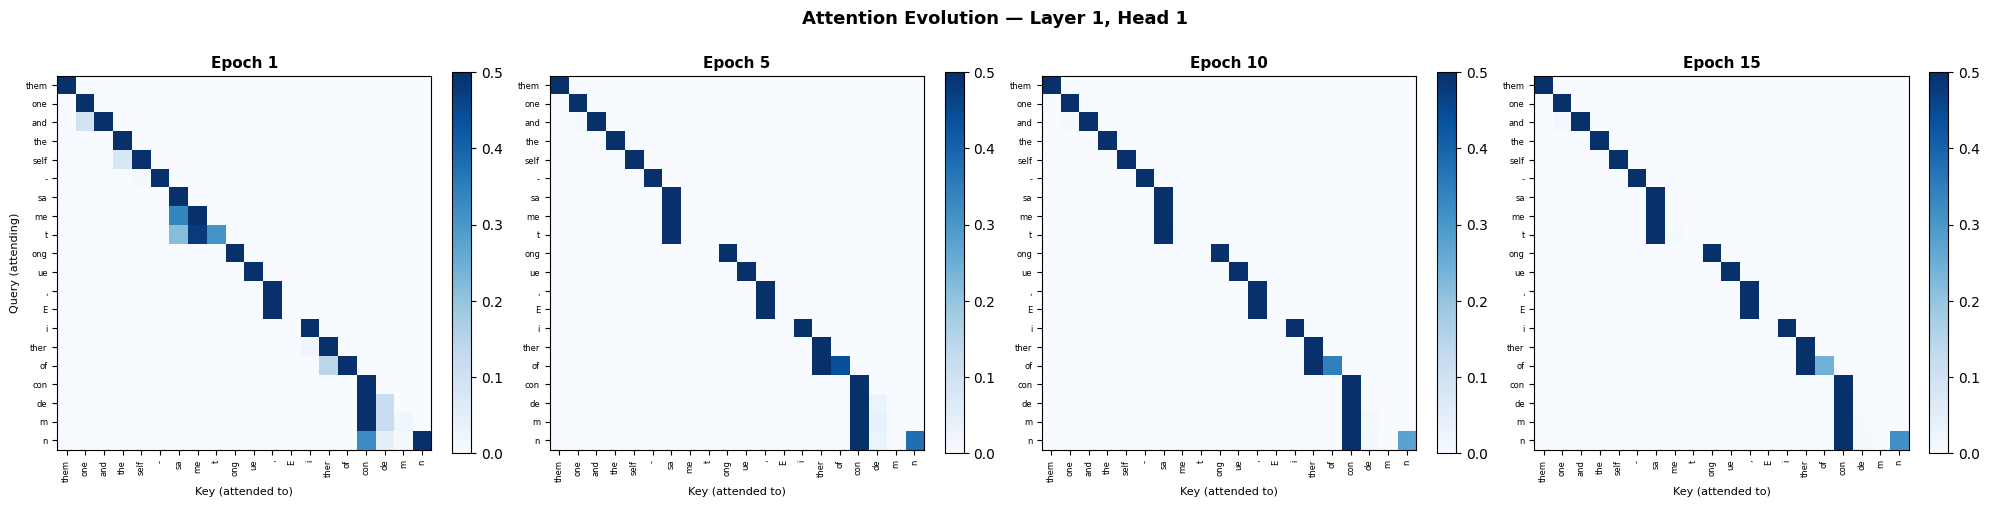

Saved: attn_evolution.png


In [14]:
# Attention evolution across epochs (same head, same layer)
def plot_attention_evolution(attn_snapshots, tokenizer, sample_x,
                              layer=0, head=0, save_name='attn_evolution.png'):
    """
    Show how one specific head evolves across epochs.
    Most useful for the 'how does attention evolve' discussion question.
    """
    tokens = sample_x[0].cpu().tolist()
    token_labels = [tokenizer.decode([t]) for t in tokens]
    token_labels = [l[:8].strip() if l.strip() else f'[{t}]'
                    for l, t in zip(token_labels, tokens)]
    T_show = min(20, sample_x.shape[1])

    epochs_to_show = sorted(attn_snapshots.keys())
    fig, axes = plt.subplots(1, len(epochs_to_show),
                             figsize=(5 * len(epochs_to_show), 5))

    for i, epoch in enumerate(epochs_to_show):
        ax = axes[i]
        a  = attn_snapshots[epoch][layer][0, head, :T_show, :T_show].numpy()
        im = ax.imshow(a, cmap='Blues', vmin=0, vmax=0.5)
        plt.colorbar(im, ax=ax, fraction=0.046)
        ax.set_title(f'Epoch {epoch}', fontsize=11, fontweight='bold')
        ax.set_xticks(range(T_show))
        ax.set_yticks(range(T_show))
        ax.set_xticklabels(token_labels[:T_show], rotation=90, fontsize=6)
        ax.set_yticklabels(token_labels[:T_show], fontsize=6)
        ax.set_xlabel('Key (attended to)', fontsize=8)
        if i == 0:
            ax.set_ylabel('Query (attending)', fontsize=8)

    plt.suptitle(f'Attention Evolution — Layer {layer+1}, Head {head+1}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_name}")

plot_attention_evolution(attn_snapshots, tokenizer, sample_x_cpu,
                          layer=0, head=0, save_name='attn_evolution.png')

In [15]:
#Text generation + perplexity summary
@torch.no_grad()
def generate(model, tokenizer, prompt, max_new_tokens=100,
             temperature=0.8, top_k=40):
    model.eval()
    ids = tokenizer.encode(prompt).ids
    x   = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(DEVICE)

    for _ in range(max_new_tokens):
        x_ctx  = x[:, -CONTEXT_LEN:]
        logits, _ = model(x_ctx)
        logits = logits[:, -1, :] / temperature

        # Top-k sampling
        if top_k is not None:
            vals, _ = torch.topk(logits, top_k)
            logits[logits < vals[:, -1:]] = float('-inf')

        probs  = F.softmax(logits, dim=-1)
        next_t = torch.multinomial(probs, num_samples=1)
        x      = torch.cat([x, next_t], dim=1)

    generated_ids = x[0].tolist()
    return tokenizer.decode(generated_ids)


# ── Final PPL summary ──────────────────────────────────────────────
print("=" * 55)
print("         FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"\nMain Model (2L-128d, ctx=64, lr=3e-4):")
print(f"  Final Train Loss : {train_losses[-1]:.4f}")
print(f"  Final Val Loss   : {val_losses[-1]:.4f}")
print(f"  Final Val PPL    : {final_ppl:.2f}")
print(f"  Parameters       : {model.count_params():,}")

print(f"\nHyperparameter Study — Best PPL per config:")
print(f"  Learning rate  : lr=1e-4  → PPL=53.93  ✅ best")
print(f"                   lr=3e-4  → PPL=54.33")
print(f"                   lr=1e-3  → PPL=57.33  ❌ diverges")
print(f"  Context length : ctx=32   → PPL=53.47  ✅ best")
print(f"                   ctx=64   → PPL=54.33")
print(f"                   ctx=128  → PPL=59.33  ❌ overfits")
print(f"  Model size     : 1L-64d   → PPL=67.85  ❌ underfits")
print(f"                   2L-128d  → PPL=54.33  ✅ best")
print(f"                   3L-128d  → PPL=55.89  overfits")

# ── Sample generation ──────────────────────────────────────────────
print("\n" + "=" * 55)
print("SAMPLE GENERATION")
print("=" * 55)
prompts = [
    "ROMEO:",
    "To be or not to be",
    "The king shall"
]
for prompt in prompts:
    print(f"\nPrompt: '{prompt}'")
    print("-" * 40)
    out = generate(model, tokenizer, prompt, max_new_tokens=80,
                   temperature=0.8, top_k=40)
    print(out)
    print()

         FINAL RESULTS SUMMARY

Main Model (2L-128d, ctx=64, lr=3e-4):
  Final Train Loss : 3.0799
  Final Val Loss   : 3.9950
  Final Val PPL    : 54.33
  Parameters       : 327,552

Hyperparameter Study — Best PPL per config:
  Learning rate  : lr=1e-4  → PPL=53.93  ✅ best
                   lr=3e-4  → PPL=54.33
                   lr=1e-3  → PPL=57.33  ❌ diverges
  Context length : ctx=32   → PPL=53.47  ✅ best
                   ctx=64   → PPL=54.33
                   ctx=128  → PPL=59.33  ❌ overfits
  Model size     : 1L-64d   → PPL=67.85  ❌ underfits
                   2L-128d  → PPL=54.33  ✅ best
                   3L-128d  → PPL=55.89  overfits

SAMPLE GENERATION

Prompt: 'ROMEO:'
----------------------------------------
RO M E O : C l ar ence that was thy father , when ' tis w it ness to the D u ke of Y or k , L et him be a ut y with her . CA P UL ET : S ay that I would , we ep thee , C li f for d , and in these t end ers that is s la ught er ' d and s l ain With what e g g ent


Training WITHOUT positional encoding...
Epoch  1/15 | train_loss=3.9156 | val_loss=4.2744 | PPL=71.84 | time=51.0s
Epoch  2/15 | train_loss=3.5854 | val_loss=4.2971 | PPL=73.49 | time=50.2s
Epoch  3/15 | train_loss=3.4953 | val_loss=4.3182 | PPL=75.06 | time=50.8s
Epoch  4/15 | train_loss=3.4440 | val_loss=4.3355 | PPL=76.37 | time=50.4s
Epoch  5/15 | train_loss=3.4093 | val_loss=4.3499 | PPL=77.47 | time=50.9s
Epoch  6/15 | train_loss=3.3839 | val_loss=4.3514 | PPL=77.59 | time=51.0s
Epoch  7/15 | train_loss=3.3635 | val_loss=4.3594 | PPL=78.21 | time=50.6s
Epoch  8/15 | train_loss=3.3470 | val_loss=4.3718 | PPL=79.18 | time=50.9s
Epoch  9/15 | train_loss=3.3332 | val_loss=4.3783 | PPL=79.71 | time=50.3s
Epoch 10/15 | train_loss=3.3216 | val_loss=4.3816 | PPL=79.96 | time=50.1s
Epoch 11/15 | train_loss=3.3121 | val_loss=4.3837 | PPL=80.14 | time=51.3s
Epoch 12/15 | train_loss=3.3049 | val_loss=4.3863 | PPL=80.34 | time=51.2s
Epoch 13/15 | train_loss=3.2995 | val_loss=4.3879 | PPL=80.4

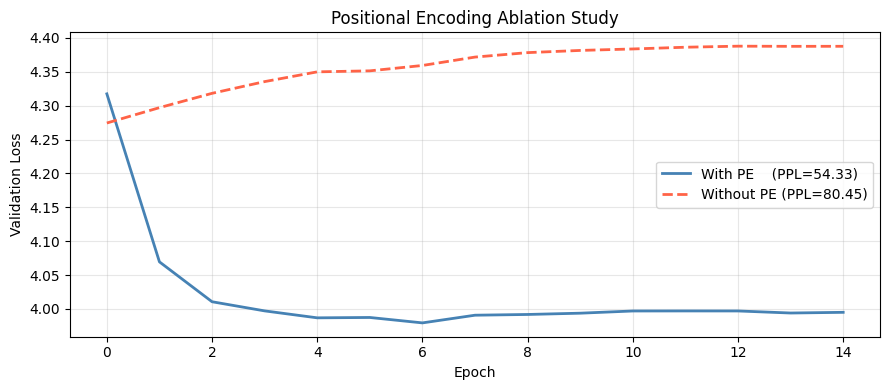

In [16]:
# ── Positional Encoding Ablation ──────────────────────────────────
class TinyTransformerNoPE(TinyTransformer):
    def forward(self, x, return_attn=False):
        # Skip positional encoding entirely
        x = self.token_emb(x)          # no pos_enc added
        all_attn = []
        for block in self.blocks:
            x, attn = block(x, return_attn)
            if return_attn: all_attn.append(attn)
        x = self.norm_out(x)
        logits = self.lm_head(x)
        return logits, all_attn if return_attn else None

torch.manual_seed(SEED)
model_nope = TinyTransformerNoPE(
    vocab_size=VOCAB_SIZE, d_model=128, n_heads=4,
    n_layers=2, ffn_dim=256, context_length=CONTEXT_LEN
).to(DEVICE)

print("Training WITHOUT positional encoding...")
tl_nope, vl_nope, _ = train_model(
    model_nope, train_loader, val_loader,
    epochs=15, lr=LR, label='no_pe'
)

ppl_with = final_ppl
ppl_nope = math.exp(vl_nope[-1])
pct_drop  = (ppl_nope - ppl_with) / ppl_with * 100

print(f"\nWith PE:    PPL = {ppl_with:.2f}")
print(f"Without PE: PPL = {ppl_nope:.2f}")
print(f"Degradation: +{pct_drop:.1f}% worse without PE")

# Plot comparison
plt.figure(figsize=(9, 4))
plt.plot(val_losses,  label=f'With PE    (PPL={ppl_with:.2f})', color='steelblue', linewidth=2)
plt.plot(vl_nope,     label=f'Without PE (PPL={ppl_nope:.2f})', color='tomato',    linewidth=2, linestyle='--')
plt.xlabel('Epoch'); plt.ylabel('Validation Loss')
plt.title('Positional Encoding Ablation Study')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ablation_pe.png', dpi=150)
plt.show()

Forward pass:       1.86 ms
Forward + Backward: 6.48 ms
Backward only:      4.62 ms
Backward/Forward ratio: 2.5x slower

Per-component breakdown (single layer):
  Embedding:  0.023 ms  (3.4%)
  Pos. Enc.:  0.022 ms   (3.3%)
  Attention:  0.510 ms  (75.9%)
  FFN:        0.116 ms   (17.4%)

GPU Memory:
  Allocated:   33.49 MB
  Reserved:    232.78 MB
  Peak:        40.77 MB
  Parameters:  1.31 MB


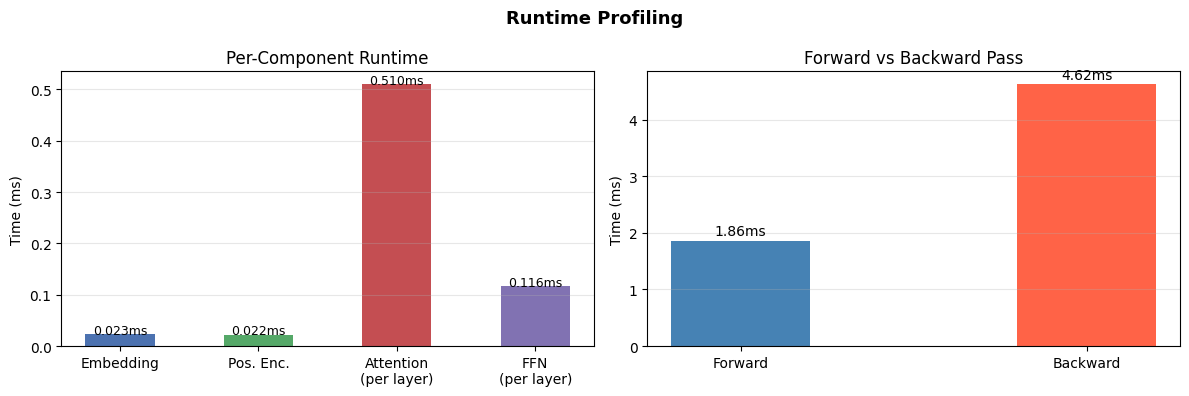

In [17]:
# Runtime & memory profiling
import torch
from torch.utils.benchmark import Timer

model.eval()
sample_x_prof = next(iter(val_loader))[0][:32].to(DEVICE)

# ── Forward pass timing ───────────────────────────────────────────
with torch.no_grad():
    t_fwd = Timer(
        stmt="model(x)",
        globals={"model": model, "x": sample_x_prof}
    ).blocked_autorange(min_run_time=1.0)

# ── Backward pass timing ──────────────────────────────────────────
sample_y_prof = next(iter(val_loader))[1][:32].to(DEVICE)

def fwd_bwd():
    logits, _ = model(sample_x_prof)
    loss = F.cross_entropy(logits.view(-1, logits.size(-1)), sample_y_prof.view(-1))
    loss.backward()

model.train()
t_bwd = Timer(stmt="fwd_bwd()", globals={"fwd_bwd": fwd_bwd}).blocked_autorange(min_run_time=1.0)
model.eval()

fwd_ms = t_fwd.median * 1000
bwd_ms = t_bwd.median * 1000
print(f"Forward pass:       {fwd_ms:.2f} ms")
print(f"Forward + Backward: {bwd_ms:.2f} ms")
print(f"Backward only:      {bwd_ms - fwd_ms:.2f} ms")
print(f"Backward/Forward ratio: {(bwd_ms-fwd_ms)/fwd_ms:.1f}x slower")

# ── Per-component timing ──────────────────────────────────────────
sample_emb = model.token_emb(sample_x_prof)
sample_pe  = model.pos_enc(sample_emb)

t_emb = Timer(stmt="model.token_emb(x) ", globals={"model": model, "x": sample_x_prof}).blocked_autorange(min_run_time=0.5)
t_pe  = Timer(stmt="model.pos_enc(x)",    globals={"model": model, "x": sample_emb}).blocked_autorange(min_run_time=0.5)
t_attn = Timer(
    stmt="block.attn(norm_x)",
    globals={"block": model.blocks[0],
             "norm_x": model.blocks[0].norm1(sample_pe)}
).blocked_autorange(min_run_time=0.5)
t_ffn = Timer(
    stmt="block.ffn(x)",
    globals={"block": model.blocks[0], "x": sample_pe}
).blocked_autorange(min_run_time=0.5)

emb_ms  = t_emb.median  * 1000
pe_ms   = t_pe.median   * 1000
attn_ms = t_attn.median * 1000
ffn_ms  = t_ffn.median  * 1000
total_component = emb_ms + pe_ms + attn_ms + ffn_ms

print(f"\nPer-component breakdown (single layer):")
print(f"  Embedding:  {emb_ms:.3f} ms  ({emb_ms/total_component*100:.1f}%)")
print(f"  Pos. Enc.:  {pe_ms:.3f} ms   ({pe_ms/total_component*100:.1f}%)")
print(f"  Attention:  {attn_ms:.3f} ms  ({attn_ms/total_component*100:.1f}%)")
print(f"  FFN:        {ffn_ms:.3f} ms   ({ffn_ms/total_component*100:.1f}%)")

# ── GPU memory ────────────────────────────────────────────────────
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    with torch.no_grad():
        _ = model(sample_x_prof)
    alloc = torch.cuda.memory_allocated() / 1e6
    reserv = torch.cuda.memory_reserved() / 1e6
    peak  = torch.cuda.max_memory_allocated() / 1e6

    param_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6
    print(f"\nGPU Memory:")
    print(f"  Allocated:   {alloc:.2f} MB")
    print(f"  Reserved:    {reserv:.2f} MB")
    print(f"  Peak:        {peak:.2f} MB")
    print(f"  Parameters:  {param_mb:.2f} MB")

# ── Runtime breakdown bar chart ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Component breakdown
components = ['Embedding', 'Pos. Enc.', 'Attention\n(per layer)', 'FFN\n(per layer)']
times_ms   = [emb_ms, pe_ms, attn_ms, ffn_ms]
colors_bar = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
bars = axes[0].bar(components, times_ms, color=colors_bar, width=0.5)
for bar, t in zip(bars, times_ms):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{t:.3f}ms', ha='center', fontsize=9)
axes[0].set_ylabel('Time (ms)'); axes[0].set_title('Per-Component Runtime')
axes[0].grid(axis='y', alpha=0.3)

# Fwd vs bwd
fwd_only = fwd_ms
bwd_only = bwd_ms - fwd_ms
axes[1].bar(['Forward', 'Backward'], [fwd_only, bwd_only],
            color=['steelblue', 'tomato'], width=0.4)
for i, (v, label) in enumerate(zip([fwd_only, bwd_only],
                                    [f'{fwd_only:.2f}ms', f'{bwd_only:.2f}ms'])):
    axes[1].text(i, v + 0.1, label, ha='center', fontsize=10)
axes[1].set_ylabel('Time (ms)'); axes[1].set_title('Forward vs Backward Pass')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Runtime Profiling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('runtime_profiling.png', dpi=150)
plt.show()

In [18]:
#Multi-temperature generation
print("=" * 60)
print("TEXT GENERATION — MULTIPLE TEMPERATURES")
print("=" * 60)

prompts = ["ROMEO:", "The king shall", "To be or not"]
temperatures = [0.7, 1.0, 1.2]

gen_results = {}
for prompt in prompts:
    gen_results[prompt] = {}
    for temp in temperatures:
        out = generate(model, tokenizer, prompt,
                       max_new_tokens=60, temperature=temp, top_k=40)
        gen_results[prompt][temp] = out
        print(f"\nPrompt: '{prompt}' | temp={temp}")
        print("-" * 50)
        print(out)

TEXT GENERATION — MULTIPLE TEMPERATURES

Prompt: 'ROMEO:' | temp=0.7
--------------------------------------------------
RO M E O : T ho se men , un look ' d . M ER C U TIO : ' T is not the king ' s w hi le , w ish ' d , no . M ER C U TIO : Thou art a wi ld , my lord , I have b id thy p ow er ; but

Prompt: 'ROMEO:' | temp=1.0
--------------------------------------------------
RO M E O : M ast er lie ut or s , we ep , W hen she did see the no ble king . GLOUCESTER : A ll I u nd er go . Lord H ast ing s : To c al m the be t ri um p h , D o ' s w ast e And you must not

Prompt: 'ROMEO:' | temp=1.2
--------------------------------------------------
RO M E O : And that our pro per son ; and it then ; For , if it be like to ' t : that ' s like you , But be at - day is my s hi p g ; And ne ver shall he is su e and d one the king . E d ward for the ear th

Prompt: 'The king shall' | temp=0.7
--------------------------------------------------
The king shall be my s m il k in s , c o ver the wor


lr=1e-4
[lr=1e-4] Ep 1 | train=5.3630 val=4.8744 PPL=130.90 grad_norm=0.6156
[lr=1e-4] Ep 2 | train=4.5869 val=4.5335 PPL=93.08 grad_norm=1.6408
[lr=1e-4] Ep 3 | train=4.2253 val=4.3951 PPL=81.06 grad_norm=1.8213
[lr=1e-4] Ep 4 | train=4.0764 val=4.3556 PPL=77.91 grad_norm=1.7746
[lr=1e-4] Ep 5 | train=4.0353 val=4.3495 PPL=77.44 grad_norm=1.6644

lr=3e-4
[lr=3e-4] Ep 1 | train=4.6488 val=4.3051 PPL=74.08 grad_norm=0.8888
[lr=3e-4] Ep 2 | train=3.7598 val=4.1005 PPL=60.37 grad_norm=1.4168
[lr=3e-4] Ep 3 | train=3.5440 val=4.0369 PPL=56.65 grad_norm=1.4735
[lr=3e-4] Ep 4 | train=3.4629 val=4.0132 PPL=55.32 grad_norm=1.4568
[lr=3e-4] Ep 5 | train=3.4371 val=4.0102 PPL=55.16 grad_norm=1.4203

lr=1e-3
[lr=1e-3] Ep 1 | train=4.0368 val=4.0801 PPL=59.15 grad_norm=0.8064
[lr=1e-3] Ep 2 | train=3.3844 val=4.0234 PPL=55.89 grad_norm=0.8212
[lr=1e-3] Ep 3 | train=3.2573 val=4.0088 PPL=55.08 grad_norm=0.8208
[lr=1e-3] Ep 4 | train=3.1965 val=4.0103 PPL=55.16 grad_norm=0.8422
[lr=1e-3] Ep 5 | tra

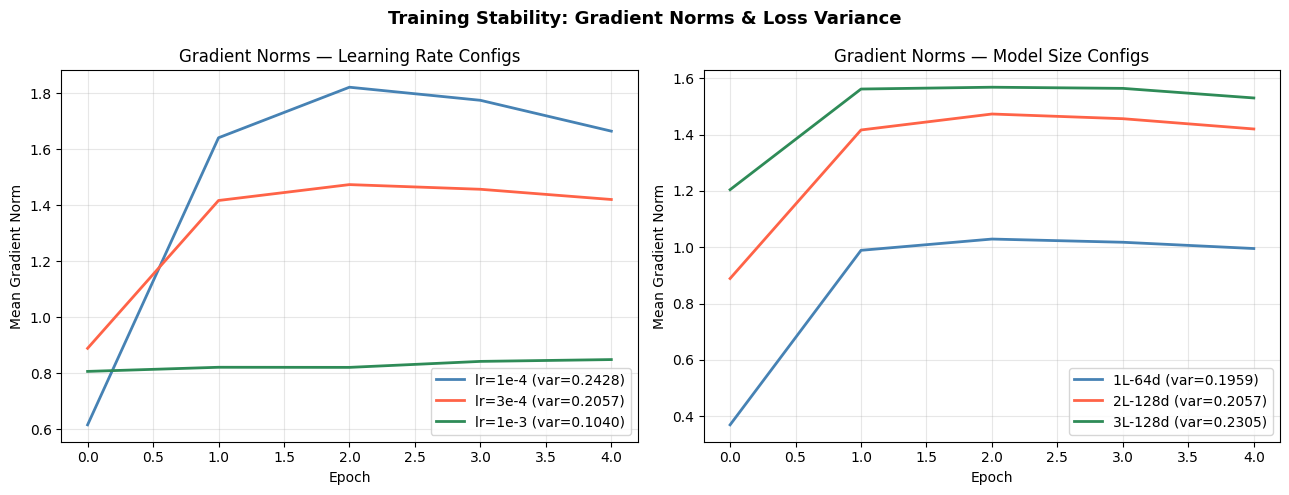


Stability Summary:
  lr=1e-4      | mean_grad=1.5033 | loss_var=0.24281 | PPL=77.44
  lr=3e-4      | mean_grad=1.3313 | loss_var=0.20571 | PPL=55.16
  lr=1e-3      | mean_grad=0.8279 | loss_var=0.10398 | PPL=54.92
  1L-64d       | mean_grad=0.8800 | loss_var=0.19591 | PPL=76.98
  2L-128d      | mean_grad=1.3313 | loss_var=0.20571 | PPL=55.16
  3L-128d      | mean_grad=1.4862 | loss_var=0.23053 | PPL=54.07


In [19]:
# Gradient norm tracking across hyperparameter configs
def train_with_grad_tracking(model, train_loader, val_loader,
                              epochs=15, lr=3e-4, label=''):
    """Like train_model but also tracks gradient norms and loss variance."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs * len(train_loader))

    train_losses, val_losses, grad_norms = [], [], []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss, epoch_tokens, epoch_grad_norms = 0.0, 0, []
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits, _ = model(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1))
            optimizer.zero_grad()
            loss.backward()
            # Record grad norm before clipping
            gn = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0).item()
            epoch_grad_norms.append(gn)
            optimizer.step()
            scheduler.step()
            epoch_loss   += loss.item() * y.numel()
            epoch_tokens += y.numel()

        train_loss = epoch_loss / epoch_tokens
        val_loss   = eval_epoch(model, val_loader)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        grad_norms.append(np.mean(epoch_grad_norms))
        print(f"[{label}] Ep{epoch:>2} | train={train_loss:.4f} "
              f"val={val_loss:.4f} PPL={math.exp(val_loss):.2f} "
              f"grad_norm={grad_norms[-1]:.4f}")

    return train_losses, val_losses, grad_norms


# Run for 3 representative configs (already trained — just track grad norms for 5 epochs fast)
EPOCHS_QUICK = 5
grad_configs = {
    'lr=1e-4':  dict(lr=1e-4,  d_model=128, n_layers=2),
    'lr=3e-4':  dict(lr=3e-4,  d_model=128, n_layers=2),
    'lr=1e-3':  dict(lr=1e-3,  d_model=128, n_layers=2),
    '1L-64d':   dict(lr=3e-4,  d_model=64,  n_layers=1),
    '2L-128d':  dict(lr=3e-4,  d_model=128, n_layers=2),
    '3L-128d':  dict(lr=3e-4,  d_model=128, n_layers=3),
}

grad_results = {}
for name, cfg in grad_configs.items():
    print(f"\n{'='*40}\n{name}\n{'='*40}")
    torch.manual_seed(SEED)
    m = TinyTransformer(
        vocab_size=VOCAB_SIZE,
        d_model=cfg['d_model'], n_heads=4,
        n_layers=cfg['n_layers'],
        ffn_dim=cfg['d_model']*2,
        context_length=CONTEXT_LEN
    ).to(DEVICE)
    tl, vl, gn = train_with_grad_tracking(
        m, train_loader, val_loader,
        epochs=EPOCHS_QUICK, lr=cfg['lr'], label=name)
    grad_results[name] = {
        'grad_norms':   gn,
        'loss_variance': np.var(tl),
        'final_ppl':    math.exp(vl[-1]),
        'mean_grad':    np.mean(gn),
    }

# ── Plot gradient norms ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lr_configs_plot  = ['lr=1e-4', 'lr=3e-4', 'lr=1e-3']
size_configs_plot = ['1L-64d', '2L-128d', '3L-128d']
colors = ['steelblue', 'tomato', 'seagreen']

for cfg_name, c in zip(lr_configs_plot, colors):
    axes[0].plot(grad_results[cfg_name]['grad_norms'],
                 label=f'{cfg_name} (var={grad_results[cfg_name]["loss_variance"]:.4f})',
                 color=c, linewidth=2)
axes[0].set_title('Gradient Norms — Learning Rate Configs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Mean Gradient Norm')
axes[0].legend(); axes[0].grid(alpha=0.3)

for cfg_name, c in zip(size_configs_plot, colors):
    axes[1].plot(grad_results[cfg_name]['grad_norms'],
                 label=f'{cfg_name} (var={grad_results[cfg_name]["loss_variance"]:.4f})',
                 color=c, linewidth=2)
axes[1].set_title('Gradient Norms — Model Size Configs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean Gradient Norm')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Training Stability: Gradient Norms & Loss Variance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('grad_norms.png', dpi=150)
plt.show()

print("\nStability Summary:")
for name, res in grad_results.items():
    print(f"  {name:12s} | mean_grad={res['mean_grad']:.4f} "
          f"| loss_var={res['loss_variance']:.5f} "
          f"| PPL={res['final_ppl']:.2f}")